In [3]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from eval.data import load_and_split
from medal.model import AutoEncoder
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

In [2]:
def load_trained_ae(ckpt_path, input_dim, hidden_dims,activation=torch.nn.SELU, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        if vec == 'none':
            continue
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

In [3]:
from itertools import combinations
from scipy.stats import spearmanr
# ---------------------------
# Pairwise Spearman rank correlation across runs
# ---------------------------
def summarize_rank_correlation(score_dict):
    """
    score_dict format:
      score_dict[hyperparam][seed] = 1D np.ndarray of scores
    """
    rows = []

    for hp, seed_to_scores in score_dict.items():
        available_seeds = sorted(seed_to_scores.keys())
        for s1, s2 in combinations(available_seeds, 2):
            rho, pval = spearmanr(seed_to_scores[s1], seed_to_scores[s2])
            rows.append({
                "hyperparam": hp,
                "seed1": s1,
                "seed2": s2,
                "spearman_rho": rho,
                "spearman_pval": pval
            })

    pairwise_df = pd.DataFrame(rows)

    summary_df = (
        pairwise_df
        .groupby("hyperparam", as_index=False)["spearman_rho"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "mean": "mean_pairwise_spearman",
            "std": "std_pairwise_spearman",
            "count": "n_pairs"
        })
    )

    return pairwise_df, summary_df

## MNIST

In [112]:
X_og, X_test, y_og, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
mnist_palette = {digit: col for digit, col in zip(y.value_counts().index, label_colors)}
cmap = sns.color_palette("BuGn", as_cmap=True)

In [5]:
tsne_param_sweep = [    5,    11,    27,    62,   146,   341,   793,  1846]
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_tsne2_{perp}_tc5_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


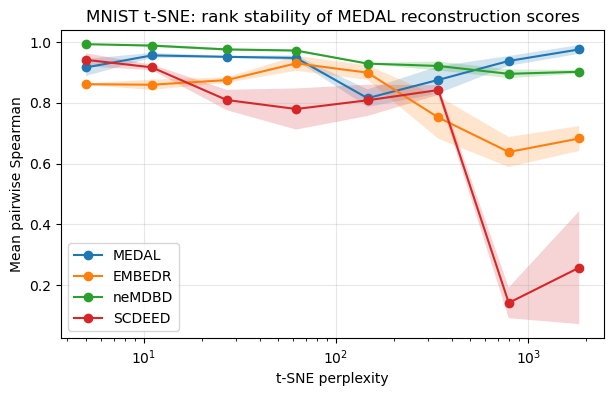

In [6]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}
for s in [0,2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/mnist_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


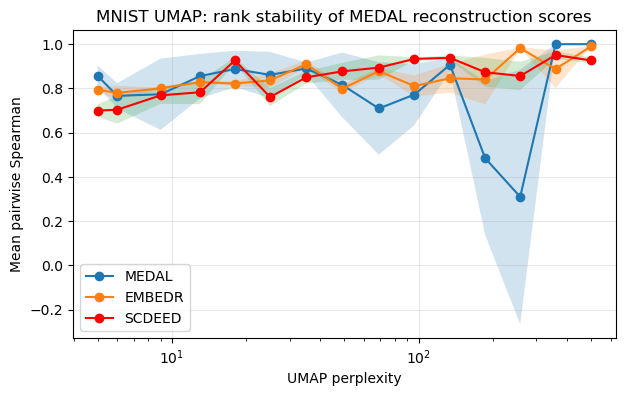

In [10]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

## Hydra

In [102]:
X_og, X_test, y_og, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

hydra_palette = color_map = {
    "enEp_tentacle": "#1e3a8a",
    "enEp_stem_cell": "#1d4ed8",
    "enEp_foot": "#2563eb",
    "enEp_head": "#3b82f6",
    "enEp-nb(pd)": "#60a5fa",
    "enEp-nem(pd)": "#93c5fd",
    "enEp_tent-nem(pd)": "#bfdbfe",
    "ecEp-nb(pd)": "#134e4a",
    "ecEp_battery_cell2(mp)": "#0f766e",
    "ecEp_stem_cell": "#0d9488",
    "ecEp_head": "#14b8a6",
    "ecEp-nem(id)": "#2dd4bf",
    "ecEp_basal_disk": "#5eead4",
    "ecEp_battery_cell1(mp)": "#99f6e4",
    "i_stem_cell/progenitor": "#4a044e",
    "i_neuron/gland_cell_progenitor": "#6b21a8",
    "i_neuron_progenitor": "#7e22ce",
    "i_nb1": "#7c2d12",
    "i_nb2": "#c2410c",
    "i_nb3": "#ea580c",
    "i_nb4": "#f97316",
    "i_nb5": "#fb923c",
    "i_neuron_ec1": "#831843",
    "i_neuron_ec2": "#be185d",
    "i_neuron_ec3": "#db2777",
    "i_neuron_ec4": "#ec4899",
    "i_neuron_ec5": "#f472b6",
    "i_neuron_en1": "#3b0764",
    "i_neuron_en2": "#5b21b6",
    "i_neuron_en3": "#7c3aed",
    "i_female_germline1": "#312e81",
    "i_female_germline2_nurse": "#4338ca",
    "i_male_germline": "#818cf8",
    "i_granular_mucous_gland_cell": "#7f1d1d",
    "i_zymogen_gland_cell": "#b91c1c",
    "i_spumous_mucous_gland_cell": "#ef4444",
    "i_nematocyte": "#92400e",
    "db": "#d97706",
}

category_map = {
    "enEp_tentacle": "enEp",
    "enEp_stem_cell": "enEp",
    "enEp_foot": "enEp",
    "enEp_head": "enEp",
    "enEp-nb(pd)": "enEp",
    "enEp-nem(pd)": "enEp",
    "enEp_tent-nem(pd)": "enEp",
    "ecEp-nb(pd)": "ecEp",
    "ecEp_battery_cell2(mp)": "ecEp",
    "ecEp_stem_cell": "ecEp",
    "ecEp_head": "ecEp",
    "ecEp-nem(id)": "ecEp",
    "ecEp_basal_disk": "ecEp",
    "ecEp_battery_cell1(mp)": "ecEp",
    "i_stem_cell/progenitor": "i_progenitors",
    "i_neuron/gland_cell_progenitor": "i_progenitors",
    "i_neuron_progenitor": "i_progenitors",
    "i_nb1": "i_neuroblasts",
    "i_nb2": "i_neuroblasts",
    "i_nb3": "i_neuroblasts",
    "i_nb4": "i_neuroblasts",
    "i_nb5": "i_neuroblasts",
    "i_neuron_ec1": "i_neurons_ec",
    "i_neuron_ec2": "i_neurons_ec",
    "i_neuron_ec3": "i_neurons_ec",
    "i_neuron_ec4": "i_neurons_ec",
    "i_neuron_ec5": "i_neurons_ec",
    "i_neuron_en1": "i_neurons_en",
    "i_neuron_en2": "i_neurons_en",
    "i_neuron_en3": "i_neurons_en",
    "i_female_germline1": "i_germline",
    "i_female_germline2_nurse": "i_germline",
    "i_male_germline": "i_germline",
    "i_granular_mucous_gland_cell": "i_gland",
    "i_zymogen_gland_cell": "i_gland",
    "i_spumous_mucous_gland_cell": "i_gland",
    "i_nematocyte": "i_nematocyte",
    "db": "db",
}
y_og_big_categories = pd.Series(y_og).map(category_map).values
y_big_categories = pd.Series(y).map(category_map).values

In [49]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(5000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_hydra_train_full_results.csv", index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024, 1024],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


In [82]:
def plot_seed_overlap_grid(
    dataset_name,
    per_sample_recon_medal_all_tsne,
    teacher, 
    perps=(5, 24, 116, 6000),
    quantiles=(0.875, 0.9),
    ref_seed=0,
    seed_labels=(0, 2, 10),
    figsize_per_panel=(4.2, 4.2),
    s_bg=5,
    s_fg=7,
    alpha_bg=0.22,
    alpha_fg=0.9,
):
    nrows = len(quantiles)
    ncols = len(perps)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False
    )

    for i, q in enumerate(quantiles):
        for j, perp in enumerate(perps):
            ax = axes[i, j]

            if teacher == '':
                embed_ref = np.load(
                    Path(PATH_PREFIX) / f"drd_data/embeddings2/{dataset_name}_tsne_{perp}_{ref_seed}_train.npy"
                )
            else:
                embed_ref = np.load(
                    Path(PATH_PREFIX) / f"drd_data/embeddings/{dataset_name}_tsne_{perp}_{ref_seed}_train_{teacher}.npy"
                )
                if teacher == 'embedr': embed_ref = embed_ref.squeeze(0)
            scores_runs = [np.asarray(per_sample_recon_medal_all_tsne[perp][x]) for x in per_sample_recon_medal_all_tsne[perp]]
            
        
            masks = [x >= np.quantile(x, q) for x in scores_runs]
            m0, m1, m2 = masks

            none   = ~(m0 | m1 | m2)
            only0  =  m0 & ~m1 & ~m2
            only1  = ~m0 &  m1 & ~m2
            only2  = ~m0 & ~m1 &  m2
            both01 =  m0 &  m1 & ~m2
            both02 =  m0 & ~m1 &  m2
            both12 = ~m0 &  m1 &  m2
            all3   =  m0 &  m1 &  m2

            ax.scatter(embed_ref[none, 0], embed_ref[none, 1],
                       c="lightgrey", s=s_bg, alpha=alpha_bg, linewidths=0)

            ax.scatter(embed_ref[only0, 0], embed_ref[only0, 1],
                       c="tab:blue", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only1, 0], embed_ref[only1, 1],
                       c="tab:orange", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only2, 0], embed_ref[only2, 1],
                       c="tab:green", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[both01, 0], embed_ref[both01, 1],
                       c="tab:purple", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both02, 0], embed_ref[both02, 1],
                       c="tab:red", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both12, 0], embed_ref[both12, 1],
                       c="tab:brown", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[all3, 0], embed_ref[all3, 1],
                       c="black", s=s_fg + 2, alpha=1.0, linewidths=0)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"perp={perp}, q={q}")

    # legend from dummy handles
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',   markersize=7, label=f"seed {seed_labels[0]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label=f"seed {seed_labels[1]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',  markersize=7, label=f"seed {seed_labels[2]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=7, label=f"{seed_labels[0]} & {seed_labels[1]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',    markersize=7, label=f"{seed_labels[0]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:brown',  markersize=7, label=f"{seed_labels[1]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',      markersize=7, label="all 3"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',  markersize=7, label="below threshold"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

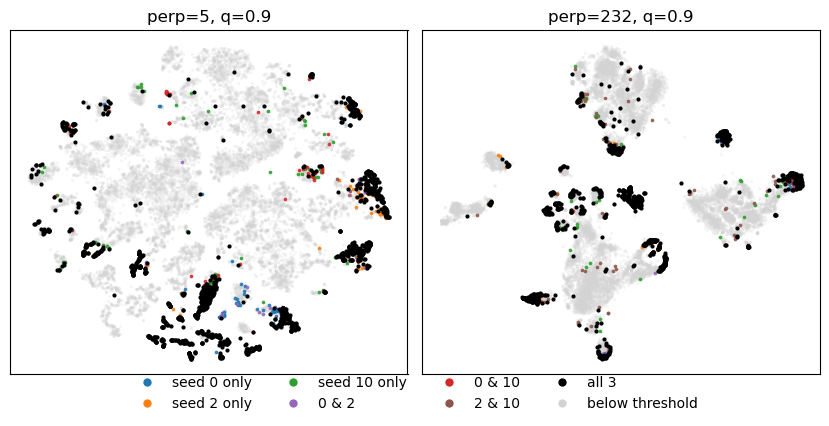

In [70]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra", teacher='',
    per_sample_recon_medal_all_tsne=per_sample_recon_medal_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

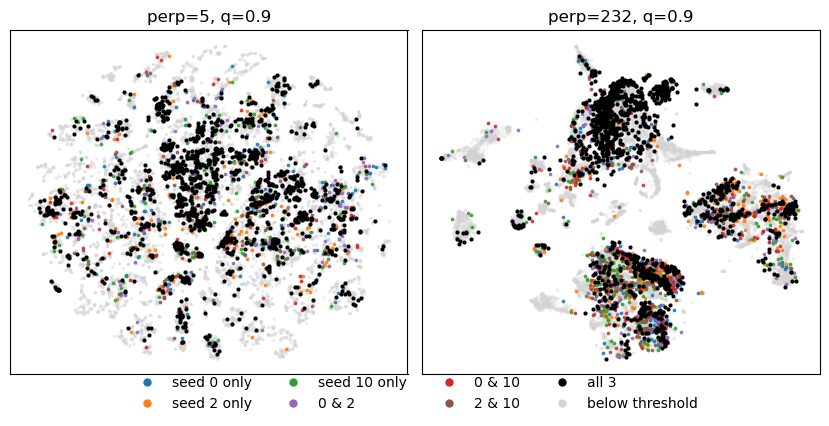

In [79]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra",teacher='pcs',
    per_sample_recon_medal_all_tsne=per_sample_recon_pcs_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

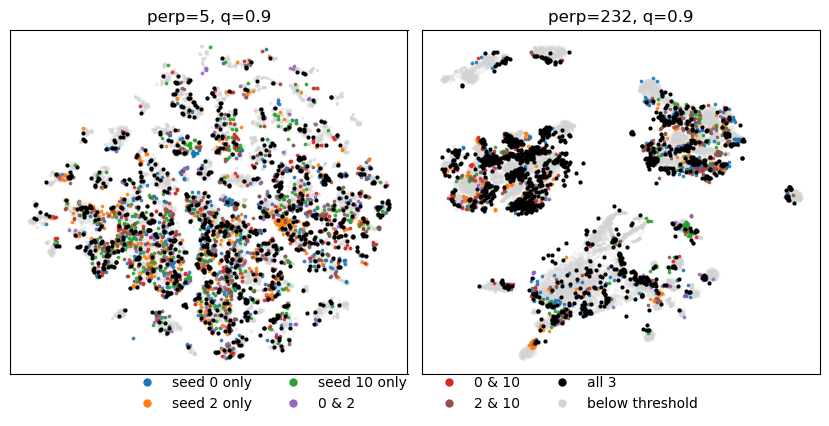

In [83]:
quantiles = np.linspace(0.875, 0.975, 20)
plot_seed_overlap_grid(
    dataset_name="hydra",teacher='embedr',
    per_sample_recon_medal_all_tsne=per_sample_recon_embedr_all_tsne,
    perps=(5, 232),
    quantiles=(0.9,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

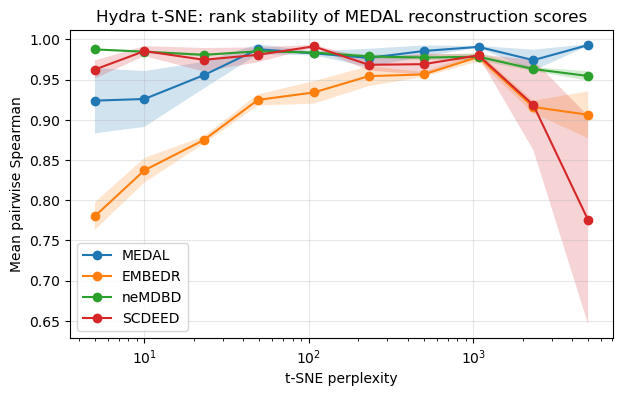

In [61]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Hydra t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [64]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}
for s in [0, 2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_hydra_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/hydra_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


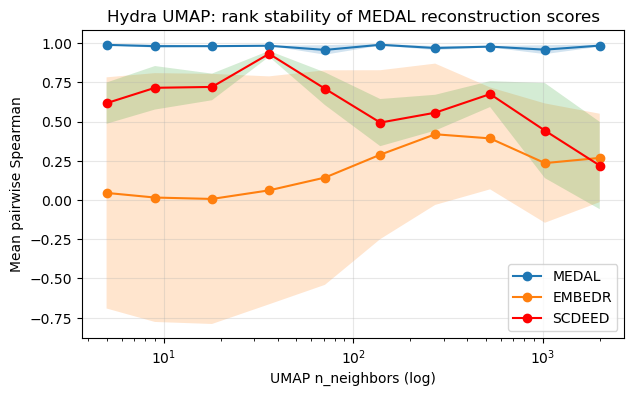

In [26]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP n_neighbors (log)")
plt.ylabel("Mean pairwise Spearman")
plt.title("Hydra UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [105]:
hydra_compare_t_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        for teacher in ["tsne", "spectral", "phate", "umap"]:
            if teacher == "umap":
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}_{n}_0.1_0_train.npy")
            elif teacher == "phate":
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}2_{n}_0_train.npy")
            else:
                teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_{teacher}_{n}_0_train.npy")
            
            if teacher == "umap":
                student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_comparison/hydra/medal_{teacher}2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024,1024],
                    latent_dim=2, batchnorm=True)
            else:
                student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_comparison/hydra/medal_{teacher}2_{n}_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[256, 1024, 1024,1024],
                    latent_dim=2, batchnorm=True)

            student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
            train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
            if train_distill < 1e-5:
                train_recon = np.mean((student_recon.detach().numpy() - X)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s, "teacher": teacher})

                x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
                val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s, "teacher": teacher})

                x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
                test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
                hydra_compare_t_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s, "teacher": teacher})
            else:
                print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

## Tasic

In [88]:
X_og, X_test, y_og, y_test = load_and_split("tasic", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_labels.npy', allow_pickle=True)
colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_colors.npy', allow_pickle=True)
categories = np.unique(labels)
tasic_palette = {cat: col for cat, col in zip(categories, colors)}

class_labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_labels.npy', allow_pickle=True)
y_class_og, y_class_test = train_test_split(class_labels, test_size=0.2, random_state=0)
y_class, y_class_val = train_test_split(y_class_og, test_size=0.2, random_state=0)
class_colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_colors.npy', allow_pickle=True)
tasic_palette_class = {"Glutamatergic": "#e5b68b", "GABAergic": "#307c47", "Non-Neuronal": "#2C94EF", "Endothelial": "#32D7FC"}

In [89]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(6000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_tasic_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


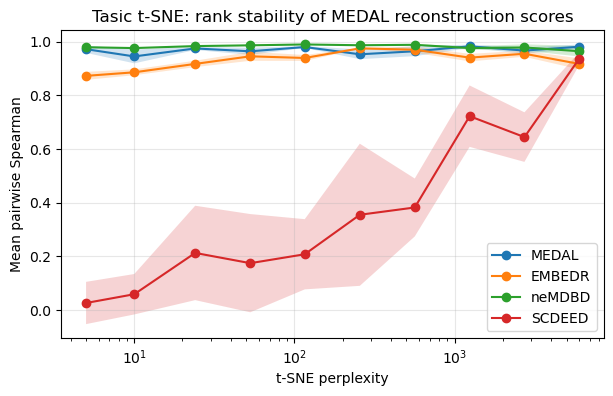

In [30]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)
pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

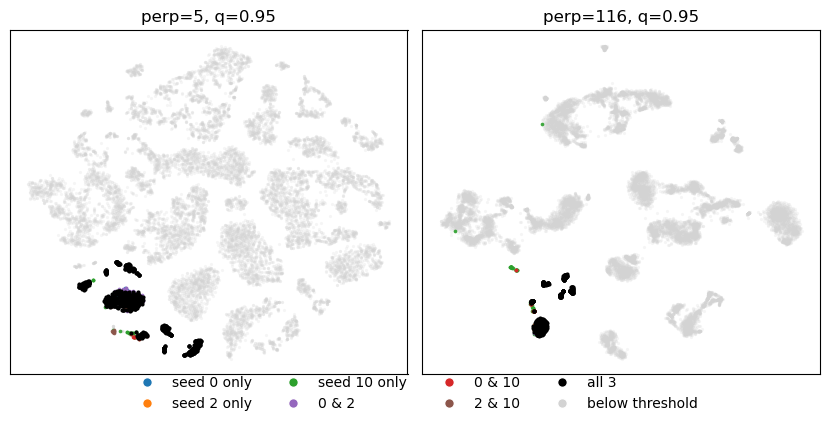

In [90]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = '',
    per_sample_recon_medal_all_tsne=per_sample_recon_medal_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

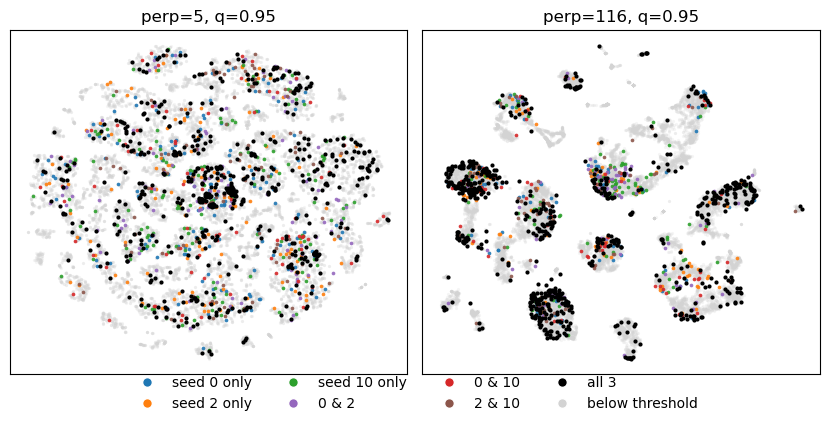

In [92]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = 'pcs',
    per_sample_recon_medal_all_tsne=per_sample_recon_pcs_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

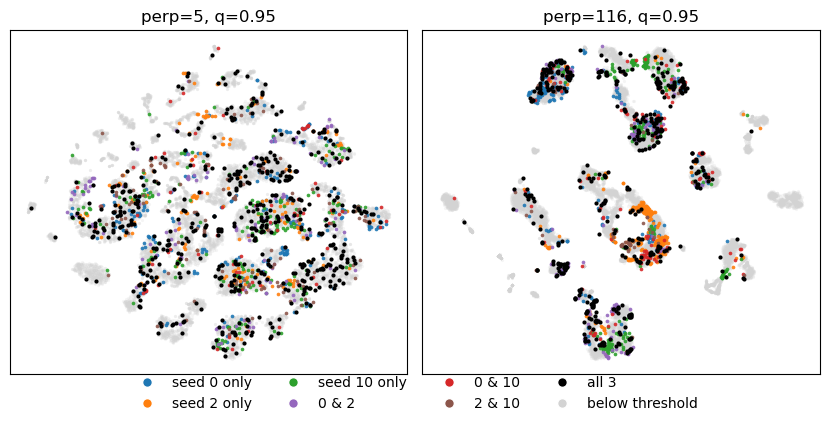

In [94]:
plot_seed_overlap_grid(
    dataset_name="tasic", teacher = 'embedr',
    per_sample_recon_medal_all_tsne=per_sample_recon_embedr_all_tsne,
    perps=(5, 116),
    quantiles=(0.95,),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

In [38]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}

for s in [0, 2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_tasic_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/tasic_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_21037/1041672765.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


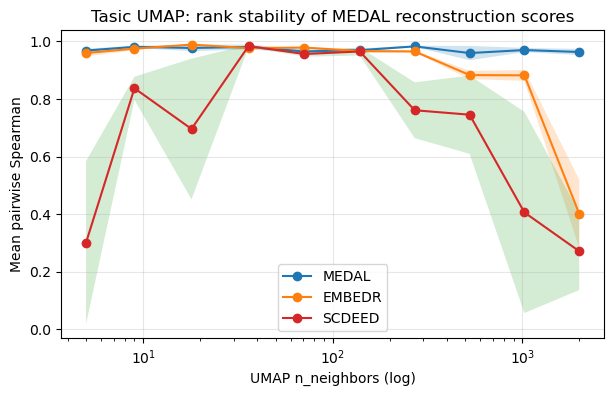

In [39]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED', color='tab:red'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP n_neighbors (log)")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

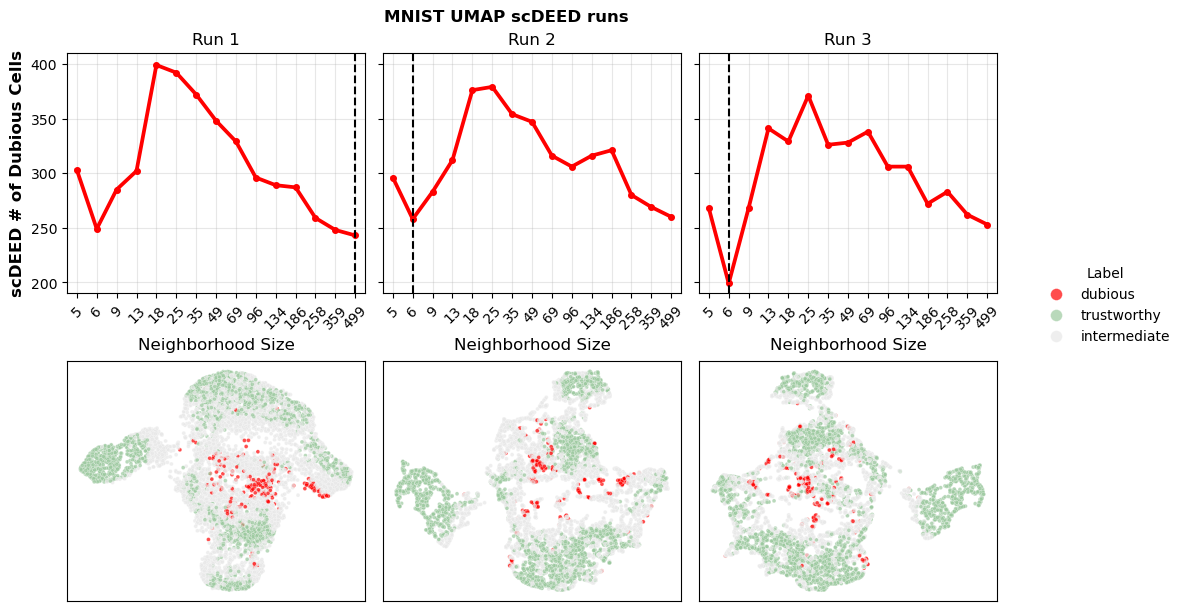

In [23]:
# showing that scdeed is inconsistent
methods = ['scdeed_1', 'scdeed_2', 'scdeed_3']
scdeed_1_best, scdeed_2_best, scdeed_3_best = 499, 6, 5
teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_1_best}_0.1_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_2_best}_0.1_0_train_2_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_3_best}_0.1_0_train_3_pc6.npy")

scdeed_df1 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed1 = split_scdeed_labels(scdeed_df1, scdeed_1_best)['label']
scdeed_df2 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0_2/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed2 = split_scdeed_labels(scdeed_df2, scdeed_2_best)['label']
scdeed_df3 = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0_3/umap_best_mnist_train_full_results.csv", index_col=0)
per_sample_scdeed3 = split_scdeed_labels(scdeed_df3, scdeed_3_best)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}

scdeed_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis1['number_dubious_cells'].idxmin()
argmin_position1 = scdeed_analysis1.index.tolist().index(umap_argmin)
scdeed_analysis2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0_2/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis2['number_dubious_cells'].idxmin()
argmin_position2 = scdeed_analysis2.index.tolist().index(umap_argmin)
scdeed_analysis3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0_3/umap_best_mnist_train_num_dubious.csv')
umap_argmin = scdeed_analysis3['number_dubious_cells'].idxmin()
argmin_position3 = scdeed_analysis3.index.tolist().index(umap_argmin)

cmap = sns.color_palette("BuGn", as_cmap=True)
fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True)
axes_flat = axes.flatten()

# 1st row 
sns.pointplot(data=scdeed_analysis1, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_title("Run 1")

sns.pointplot(data=scdeed_analysis2, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[1])
axes_flat[1].axvline(x = argmin_position2, ls = '--', c ='black')
axes_flat[1].set_title("Run 2")

sns.pointplot(data=scdeed_analysis3, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[2])
axes_flat[2].axvline(x = argmin_position3, ls = '--', c ='black')
axes_flat[2].set_title("Run 3")
axes_flat[0].set_ylabel("scDEED # of Dubious Cells", fontsize=12, fontweight='bold')

axes_flat[1].set_ylabel("")
axes_flat[2].set_ylabel("")

# 2nd row 
sns.scatterplot(x=teacher_embed['scdeed_1'][:, 0], y=teacher_embed['scdeed_1'][:, 1], 
                ax=axes_flat[3], s=8, hue = per_sample_scdeed1, palette = palette_scdeed, legend=True, alpha=0.7)
sns.scatterplot(x=teacher_embed['scdeed_2'][:, 0], y=teacher_embed['scdeed_2'][:, 1], 
                ax=axes_flat[4], s=8, hue = per_sample_scdeed2, palette = palette_scdeed, legend=False, alpha=0.7)
sns.scatterplot(x=teacher_embed['scdeed_3'][:, 0], y=teacher_embed['scdeed_3'][:, 1], 
                ax=axes_flat[5], s=8, hue = per_sample_scdeed3, palette = palette_scdeed, legend=False, alpha=0.7)
# axes_flat[3].set_ylabel(f"UMAP(n_neighbors={scdeed_1_best})")

# Legend
handles, labels = axes_flat[3].get_legend_handles_labels()
axes_flat[3].legend_.remove()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.1, 0.5), 
           frameon=False, title='Label', ncol=1, fontsize=10, markerscale=3, title_fontsize=10)

for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_ylim(190, 410)
    axes_flat[i].set_xlabel("Neighborhood Size", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')

for ax in axes_flat[3:]:
    ax.set_yticks([])
    ax.set_xticks([])
axes_flat[1].set_yticklabels([])
axes_flat[2].set_yticklabels([])

fig.suptitle("MNIST UMAP scDEED runs", fontweight='bold')
plt.show()

In [4]:
# plt.figure(figsize=(10,7))
mnist_by_k_tsne = pd.read_csv('tasic_by_k_tsne_all_methods.csv', index_col=0)
# mnist_by_k_tsne.reset_index(names='k', inplace=True)
mnist_by_k_tsne[['triplet_accuracy', 'spearman_rho', 'method', 'lcmc_mean']].drop_duplicates().sort_values('triplet_accuracy')
# mnist_by_k_tsne = mnist_by_k_tsne.loc[mnist_by_k_tsne.k <= 50]
# mnist_by_k_tsne.loc[:, 'lcmc_mean'] = mnist_by_k_tsne.groupby(['method', 'split'])['lcmc'].transform('mean')
# mnist_by_k_tsne.reset_index(names='k', inplace=True)
# mnist_by_k_tsne = mnist_by_k_tsne.loc[mnist_by_k_tsne.k <= 50].
# sns.pointplot(data = mnist_by_k_tsne[(mnist_by_k_tsne.split=='Test') & (mnist_by_k_tsne.method.isin(['MEDAL_49', 'MEDAL_499']) )], x = 'k', hue='method', y='lcmc', markersize=2, alpha = 0.5)

,triplet_accuracy,spearman_rho,method,lcmc_mean
10,0.5872,0.309098,PCS_SEED0 (5),0.454391
10,0.7952,0.719650,MEDAL_SEED0 (6000),0.449893
10,0.7964,0.707899,EMBEDR_SEED0 (2729),0.486008
10,0.7968,0.737975,SCDEED_SEED0 (2729),0.557916
